In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import pdb
from scipy import integrate
import matplotlib as mpl
from scipy import interpolate
import time

from ABM_package import *

In [3]:
rp = 0.5
rd = rp/2
rm = 1.0
f = 2
den0 = .05

A_out, t_out, plot_list, interp_profiles = BDM_ABM(rp,rd,rm,f,den0, T_end=50.0)

Running ABM:   0%|          | 0/50 [00:00<?, ?it/s]

Running ABM: 100%|██████████| 50/50 [08:23<00:00, 10.07s/it]


In [16]:
from scipy import interpolate
import numpy as np

# Assume t_list contains the times when each plot in plot_list was saved
# If you didn't save t_list for snapshots, you can reconstruct roughly as:
num_snapshots = len(plot_list)
T_final = t_out[-1]
snapshot_times = np.linspace(0, T_final, num_snapshots)

# Interpolate F_values onto t_out
F_values = np.array([compute_F(A) for A in plot_list])
F_out = interpolate.interp1d(snapshot_times, F_values, kind='linear')(t_out)

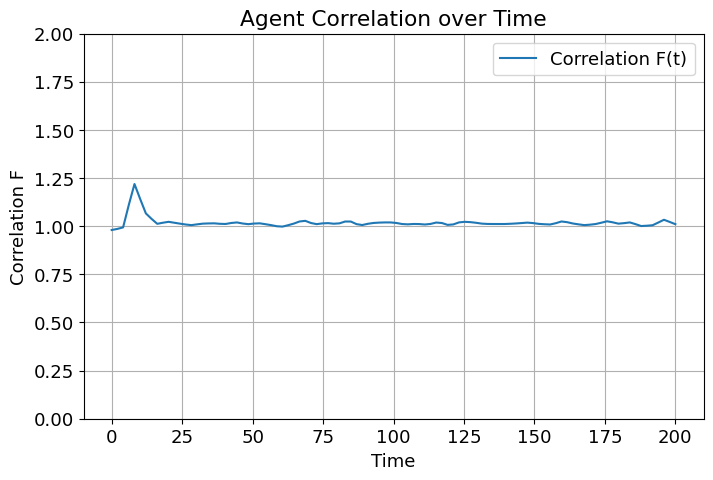

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(t_out, F_out, label='Correlation F(t)', color='tab:blue')
plt.xlabel('Time')
plt.ylabel('Correlation F')
plt.title('Agent Correlation over Time')
plt.grid(True)
plt.legend()

# Make y-axis start at 0
plt.ylim(bottom=0, top=2)

plt.show()



In [18]:
F_ss = F_out.mean()  # average over last 10 timepoints
print("average correlation", F_ss)


average correlation 1.0184289090860938


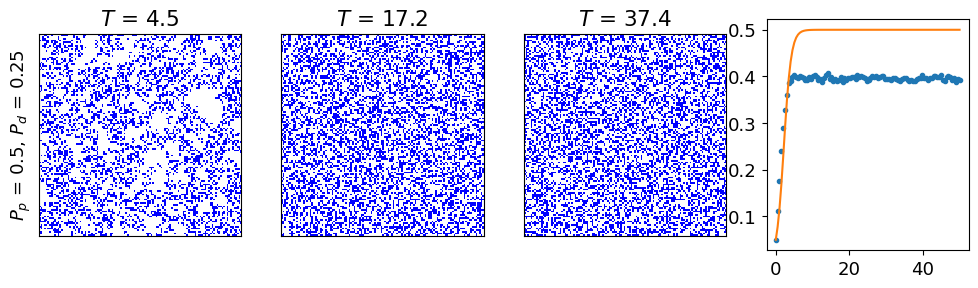

In [19]:
plot_ind = [2,7,15]

cmaplist = [(1.0,1.0,1.0,1.0),(0.0,0.0,1.0,1.0)]
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, N = 2)

font = {'size'   : 13}

plt.rc('font', **font)

fig = plt.figure(figsize=(12,3))

ax = fig.add_subplot(1,4,4,adjustable='box')

r = rp-rd
K = r/rp
c0 = 0.05
logist = K*c0*(np.e**(r*t_out))/(K + c0*(np.e**(r*t_out)-1))

ax.plot(t_out*(rp-rd),A_out/plot_list[0].size,'.')
ax.plot(t_out*(rp-rd),logist)

for i in np.arange(3):

    ax = fig.add_subplot(1,4,1+i,adjustable='box')
    ax.matshow(plot_list[plot_ind[i]],cmap=cmap,vmin=0,vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("$T$ = " + str(round(t_out[plot_ind[i]*5-1]*(rp-rd),1)))

    if i == 0:
        ax.set_ylabel("$P_p$ = "+str(rp)+", $P_d$ = "+str(rd))

plt.savefig("nf_plot"+ str(f)+ ".pdf")